<a id="TMP_04c2"></a>

# <span style="color:rgb(213,80,0)">Geospatial Data Analysis and Visualization</span>
<!-- Begin Toc -->

## Table of Contents
&#8195;[Import Data (Excel)](#TMP_4f74)

&#8195;[Visualize Data](#TMP_662c)

&#8195;[Import Data (shape file, netcdf)](#TMP_1125)

&#8195;[Convert Scattered Data to a Raster Grid](#TMP_6990)

&#8195;[Map with Georeferenced Image](#TMP_3167)

<!-- End Toc -->
<a id="TMP_4f74"></a>

## Import Data (Excel)

Import the data from tsunamis.xlsx. Use the Import Data tool or Live task to automatically generate the code you need.


In [1]:
%% Import data from spreadsheet
% Script for importing data from the following spreadsheet:
%
%    Workbook: C:\Users\lsammon\OneDrive - MathWorks\Documents\MATLAB\4_Seminars\CIMAS 2026\CIMASspring26\Data\tsunamis.xlsx
%    Worksheet: Sheet1
%
% Auto-generated by MATLAB on 22-Apr-2026 11:09:17


%% Set up the Import Options and import the data
opts = spreadsheetImportOptions("NumVariables", 20);


% Specify sheet and range
opts.Sheet = "Sheet1";
opts.DataRange = "A2:T163";


% Specify column names and types
opts.VariableNames = ["Latitude", "Longitude", "Year", "Month", "Day", "Hour", "Minute", "Second", "ValidityCode", "Validity", "CauseCode", "Cause", "EarthquakeMagnitude", "Country", "Location", "MaxHeight", "IidaMagnitude", "Intensity", "NumDeaths", "DescDeaths"];
opts.VariableTypes = ["double", "double", "double", "double", "double", "double", "double", "double", "double", "categorical", "double", "categorical", "double", "categorical", "categorical", "double", "double", "double", "double", "double"];


% Specify variable properties
opts = setvaropts(opts, ["Validity", "Cause", "Country", "Location"], "EmptyFieldRule", "auto");


% Import the data
tsunamis = readtable("tsunamis.xlsx", opts, "UseExcel", false);


%% Clear temporary variables
clear opts




<a id="TMP_662c"></a>

## Visualize Data

Quickly visualize data on a geographic axes.



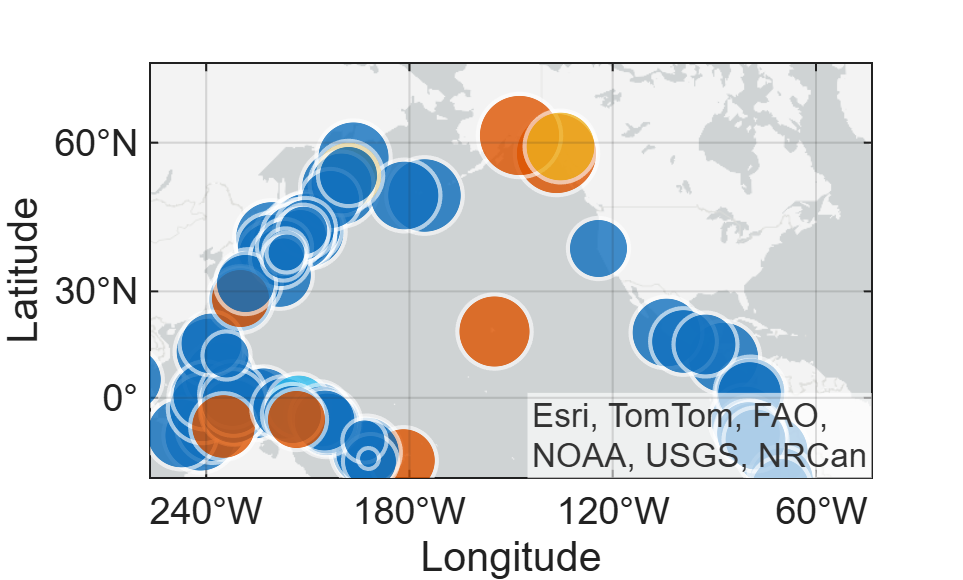

In [2]:
figure
geobubble(tsunamis.Latitude,tsunamis.Longitude,tsunamis.Intensity,tsunamis.Cause)


geolimits([-52 73],[-253 -17])

In [3]:
% make your map more informative while still being digestible
% filter out the "undefined" cause tsunamis


indx = ismissing(tsunamis.Cause); % or put all the logical indexing in 1 line
tsunamis(indx,:) = [];


% add a few interactive Live controls for minimum tsunami size and validity
% code. View only tsunamis of one cause type.


minMagnitude = 2;


unique(tsunamis.Cause)

ans = 7x1 categorical
Earthquake                
Earthquake and Landslide  
Landslide                 
Meteorological            
Unknown Cause             
Volcano                   
Volcano and Landslide


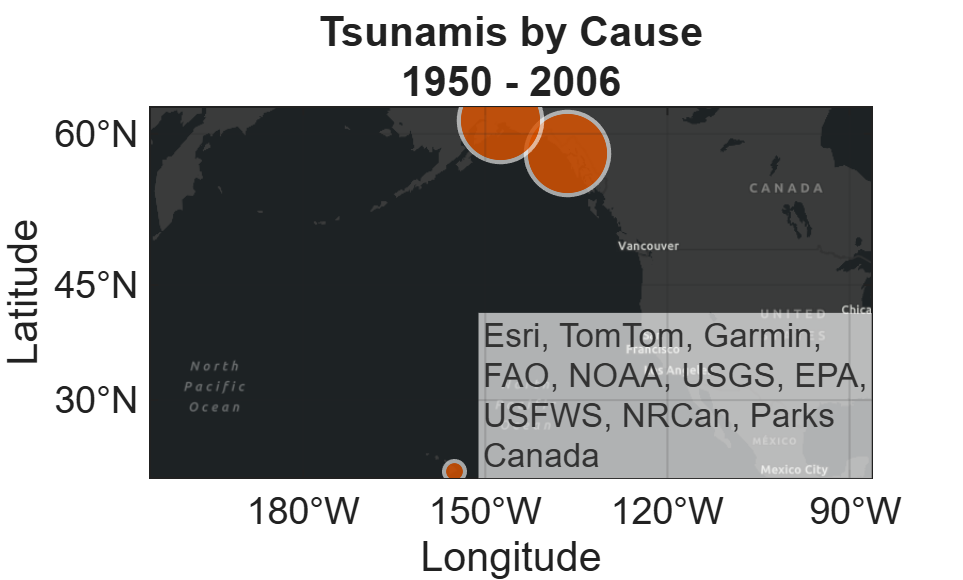

In [4]:
cause = "Earthquake and Landslide";


indxData = tsunamis.Cause == cause & tsunamis.Intensity >= minMagnitude;


% Plot geospatial bubbles sized by intensity and colored by cause
figure
geobubble(tsunamis.Latitude(indxData),tsunamis.Longitude(indxData),...
    tsunamis.Intensity(indxData),tsunamis.Cause(indxData))
% Use a blue-green basemap for geographic context
geobasemap('streets-dark')
% Title showing the span of years in the dataset
title({'Tsunamis by Cause'; [num2str(min(tsunamis.Year)),' - ', num2str(max(tsunamis.Year))]})

<a id="TMP_1125"></a>

## Import Data (shape file, netcdf)


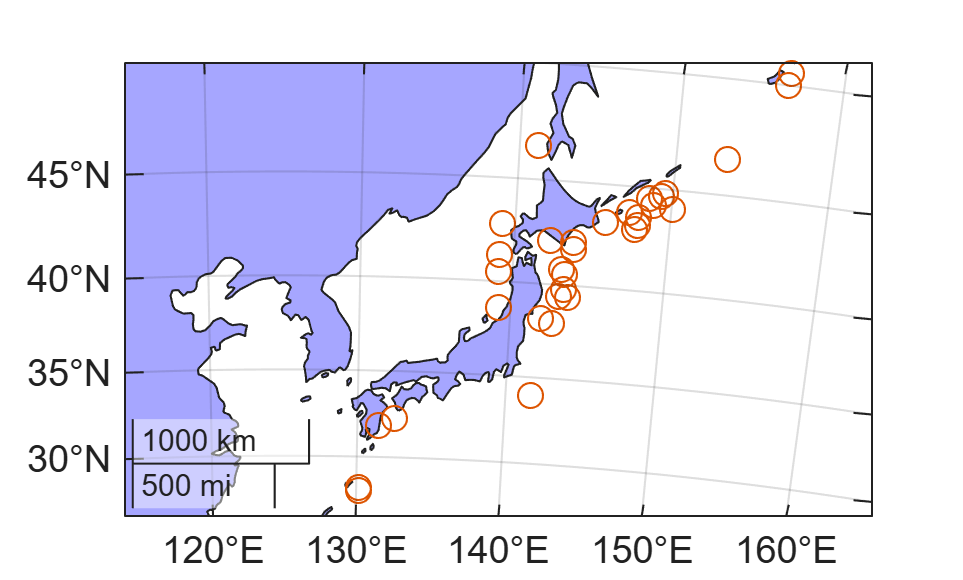

In [5]:
% Read land area features from a shapefile into a GeoTable
land = readgeotable("landareas.shp");
% Create a subset by excluding the 4th record (keep 1-3 and 5-end)
subland = land([1:3,5:end],:);
% Create a projected CRS using ESRI code 102030
proj = projcrs(102030,Authority="ESRI");


figure
newmap(proj)
geoplot(subland,FaceColor="blue")
geolimits([25 50],[125 150])


hold on


geoscatter(tsunamis.Latitude,tsunamis.Longitude)

<a id="TMP_6990"></a>

## Convert Scattered Data to a Raster Grid

In [6]:
load ("oceanDepth.mat")


[Z, R] = geoloc2grid(oceanDepth.lat,oceanDepth.lon,oceanDepth.depth,1);


If your data are scattered across an irregular grid (non\-uniform sampling intervals) use [scatteredInterpolant](https://www.mathworks.com/help/matlab/ref/scatteredinterpolant.html).



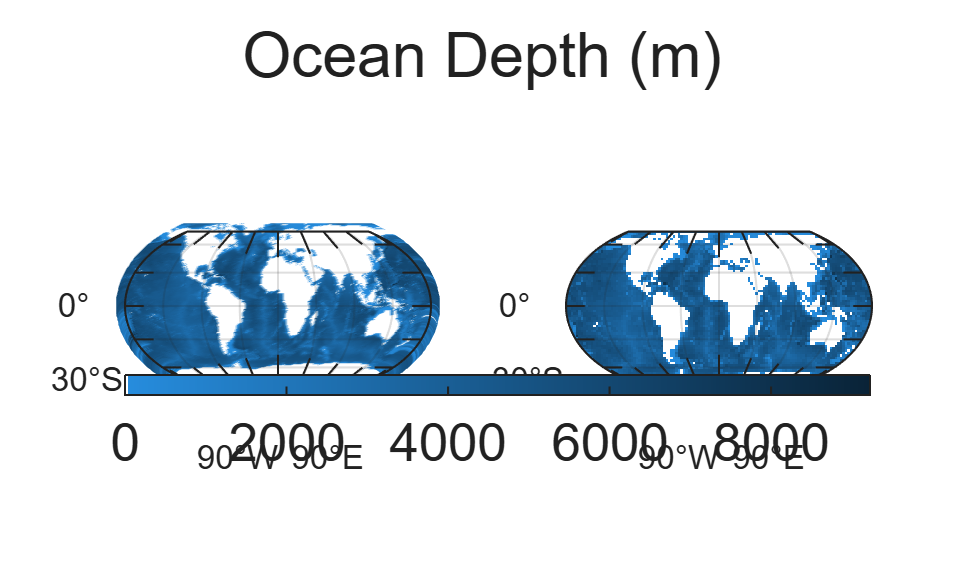

In [7]:
f = figure;
tiledlayout(1,2);
nexttile
newmap
geoscatter(oceanDepth.lat,oceanDepth.lon,20,oceanDepth.depth,"filled")


nexttile
newmap
geopcolor(Z,R)


h = axes(f,"Visible","off");
colormap([1 1 1; flipud(abyss)])
colorbar(h,'southoutside')
clim([0 max(oceanDepth.depth)])
sgtitle(f,'Ocean Depth (m)')

<a id="TMP_3167"></a>

## Map with Georeferenced Image


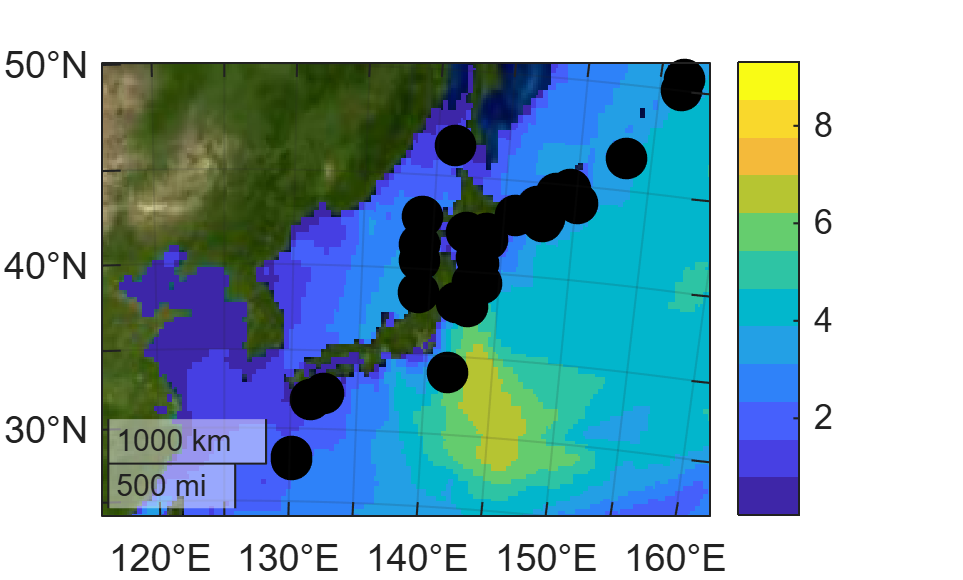

In [8]:
info = georasterinfo("20240116120000-0h-wave-fc.grib2");
[A,R] = readgeoraster("20240116120000-0h-wave-fc.grib2","Bands",1);


land = imread("landOcean.jpg");
Rland = georefcells([-90 90],[-180 180],size(land),"ColumnsStartFrom","north");


proj = projcrs(102030,Authority="ESRI"); % lambert projection for SE Asia


figure
newmap(proj)
geoimage(land,Rland)
hold on


geopcolor(A,R)
geoscatter(tsunamis.Latitude,tsunamis.Longitude,100,'filled','k')


colormap(parula(12))
colorbar
geolimits([25 50],[125 150])